In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


# Import

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# EDA

In [3]:
train_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/train.csv")
test_data = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/test.csv")

## EDA on training Data

In [4]:
train_data.shape

(630000, 21)

In [7]:
train_data.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [9]:
train_data.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [11]:
train_data.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [12]:
train_data.duplicated().sum()

np.int64(0)

In [11]:
# train_data.corr()

## Univariate Analysis on Categorical Features

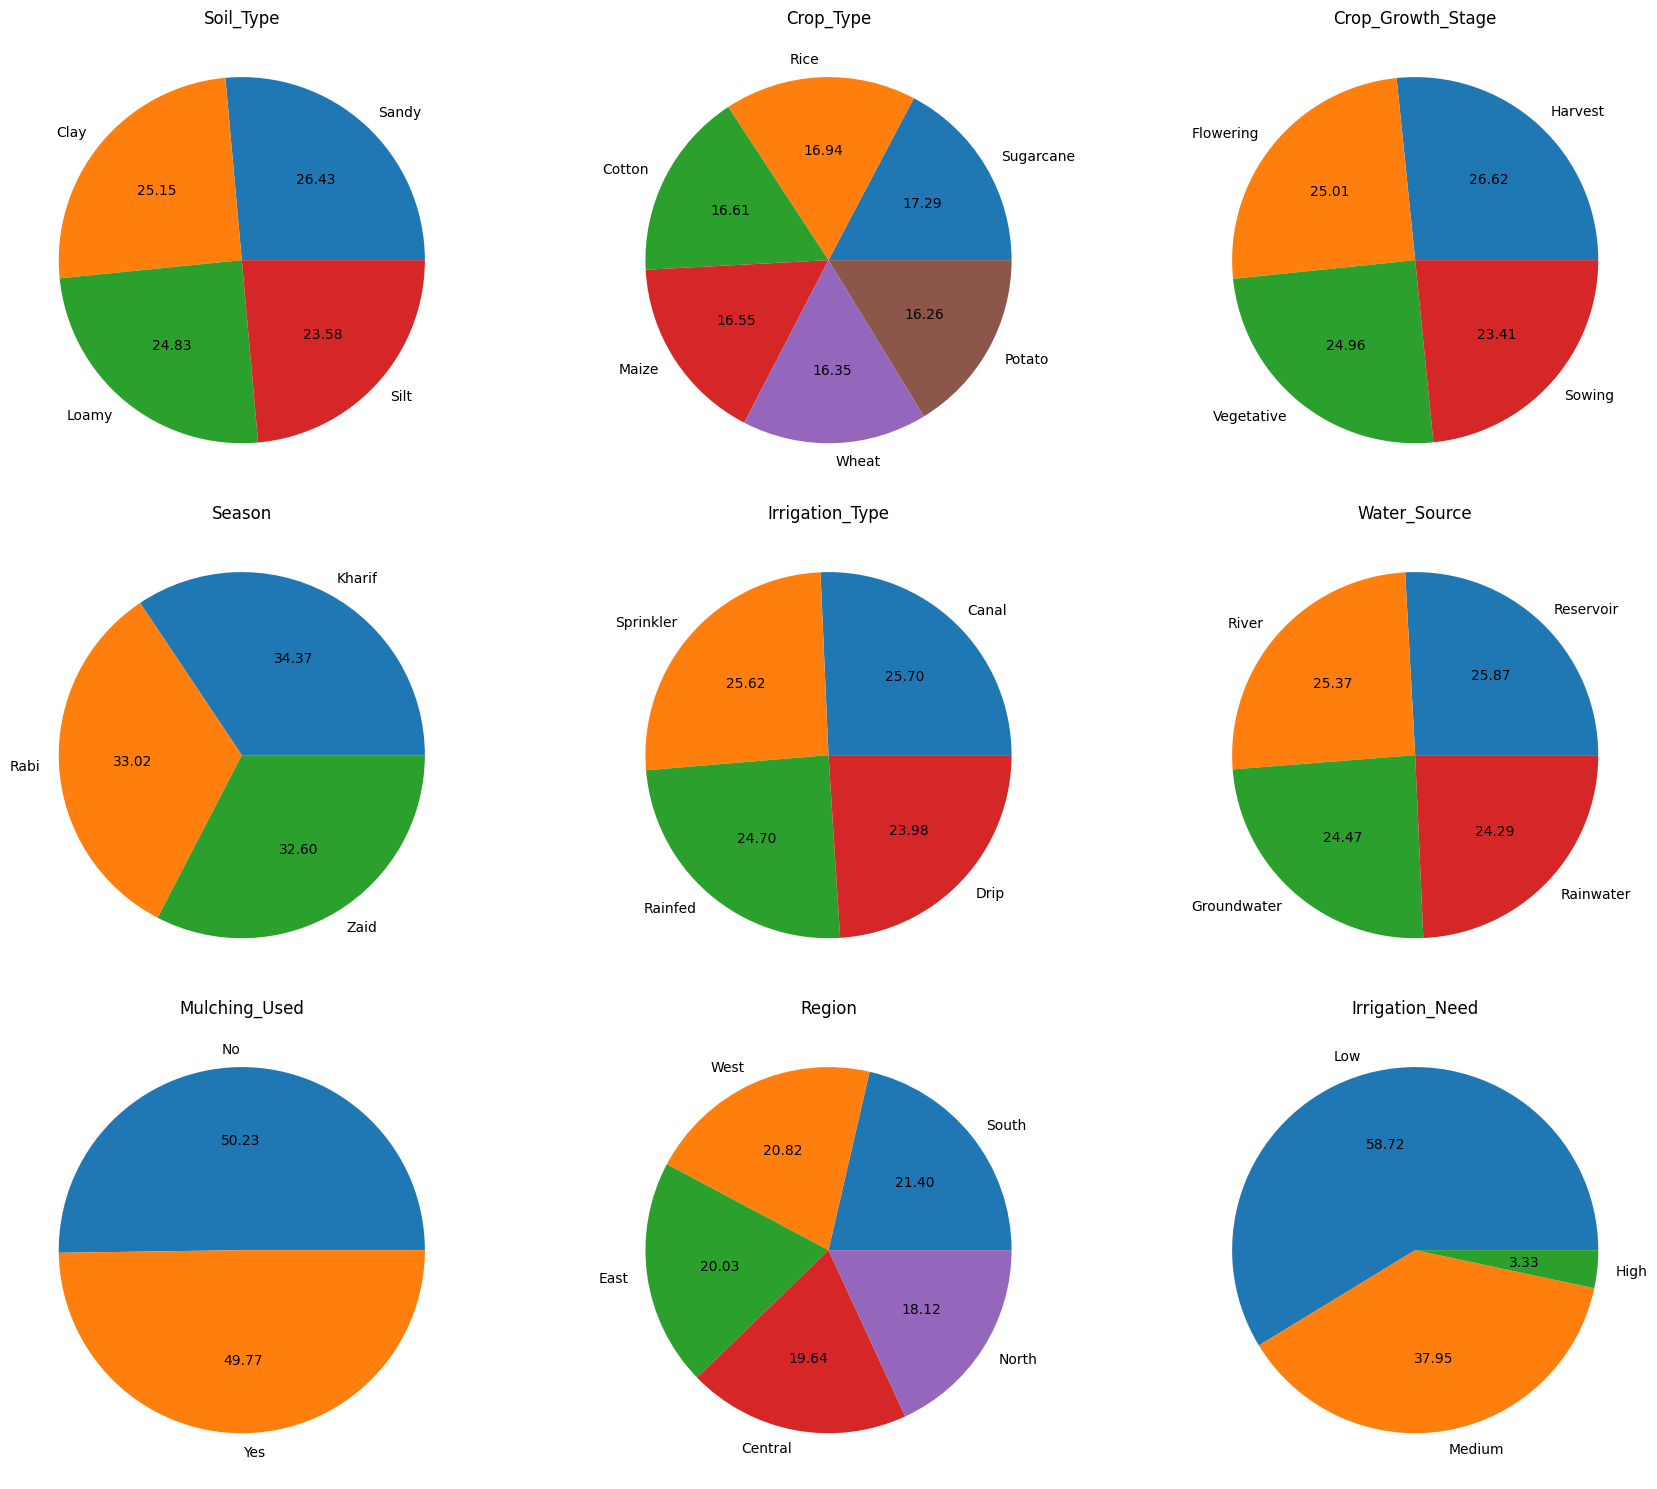

In [55]:
Cat_Cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type',
            'Water_Source','Mulching_Used', 'Region', 'Irrigation_Need' ] 

fig , axes = plt.subplots(3,3, figsize=(18,15))
axes = axes.flatten()


for i,col in enumerate(Cat_Cols):
    train_data[col].value_counts().plot(kind='pie', autopct='%.2f' , ax = axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## Univariate Analysis on Numerical Features

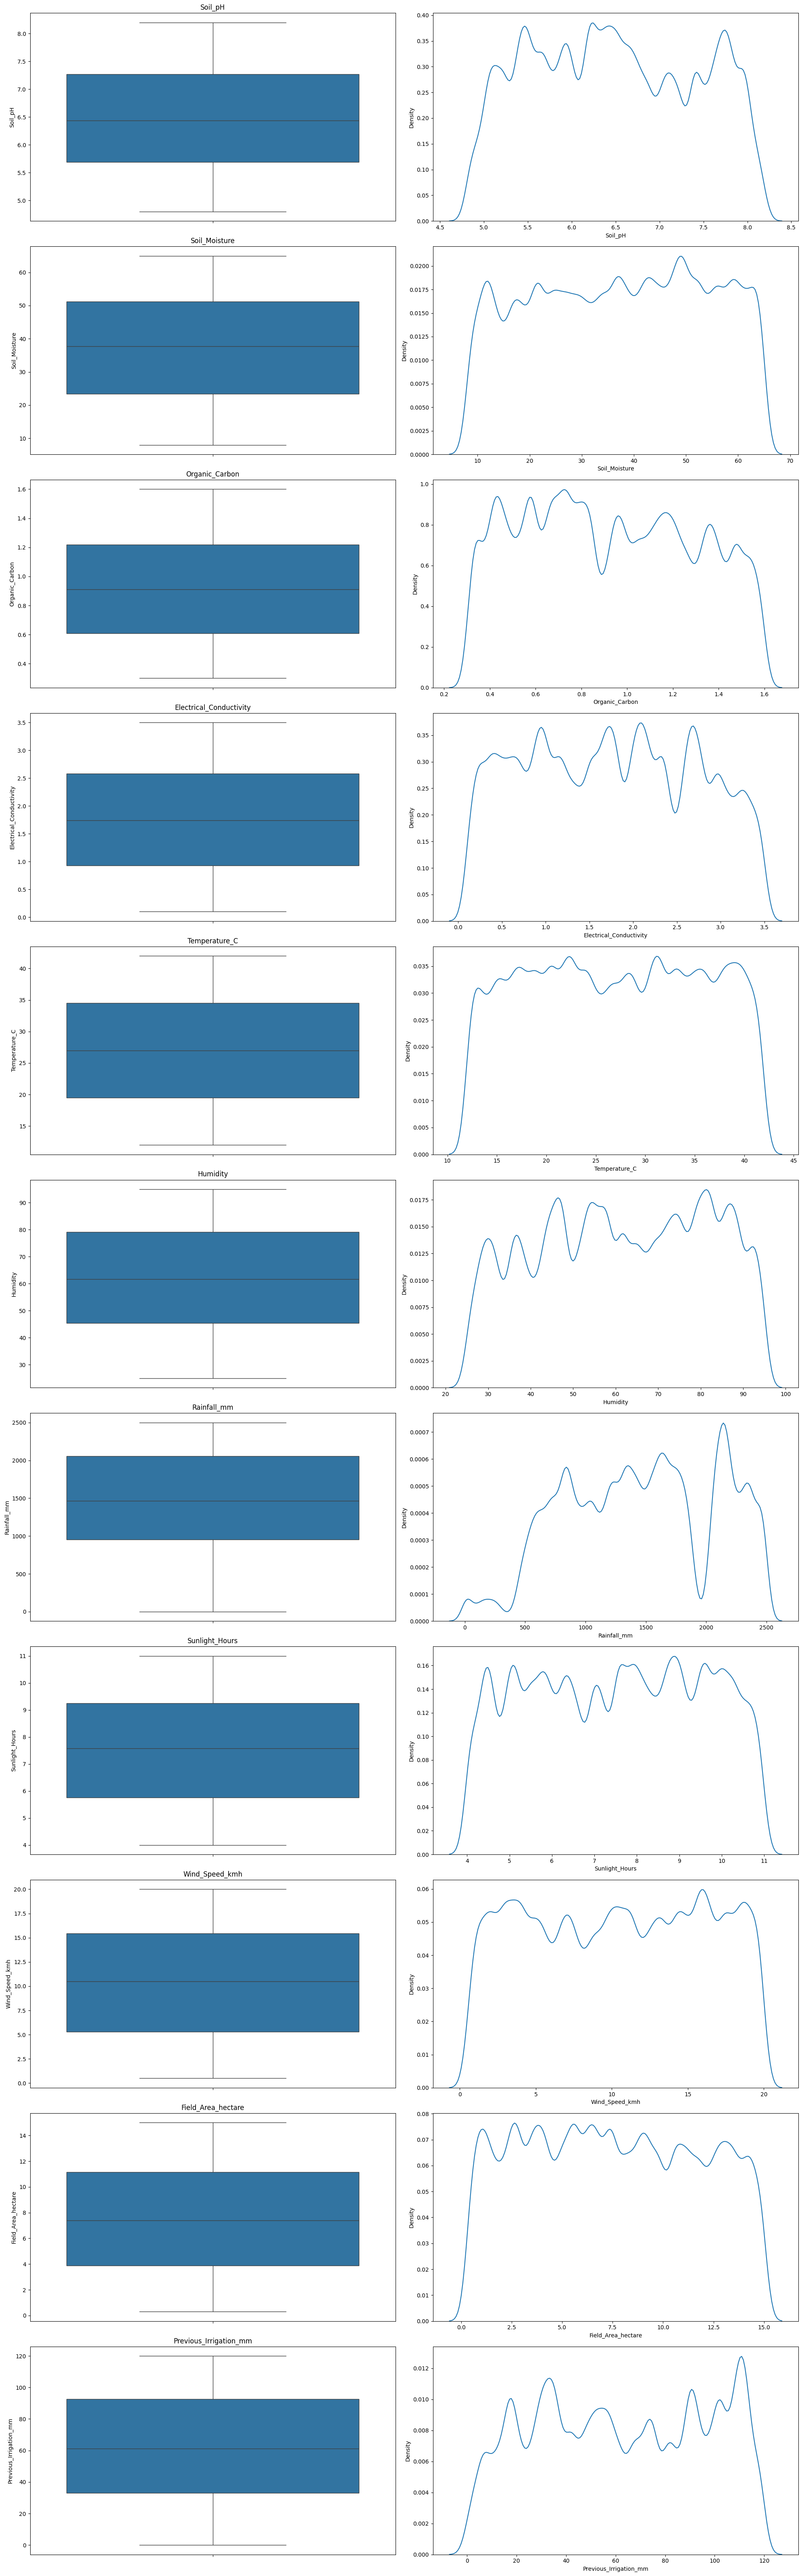

In [87]:
Num_Cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C',
           'Humidity', 'Rainfall_mm','Sunlight_Hours', 'Wind_Speed_kmh',
            'Field_Area_hectare','Previous_Irrigation_mm' ]
fig , axes = plt.subplots(11,2, figsize=(20, 64))
axes = axes.flatten()
for i ,col in enumerate(Num_Cols):
    idx = i * 2
    sns.boxplot(train_data[col] , ax=axes[idx])
    axes[idx].set_title(col)
    
    sns.kdeplot(train_data[col] , ax=axes[idx+1])
    axes[idx].set_title(col)
    
plt.tight_layout()
plt.show()
        
     

## EDA on Test Data

In [12]:
test_data.shape

(270000, 20)

In [13]:
test_data.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [14]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [15]:
test_data.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000
mean,764999.500000,6.480929,37.307614,0.922279,1.745251,27.001666,61.511319,1464.525885,7.513277,10.386531,7.508192,62.356021
std,77942.430678,0.922187,16.375273,0.365757,0.951329,8.630706,19.690278,612.521709,2.002661,5.683215,4.218736,34.225278
min,630000.000000,4.800000,8.010000,0.300000,0.100000,12.010000,25.000000,1.640000,4.000000,0.500000,0.300000,0.020000
25%,697499.750000,5.680000,23.340000,0.610000,0.930000,19.500000,45.310000,956.100000,5.760000,5.320000,3.880000,33.190000
50%,764999.500000,6.440000,37.770000,0.900000,1.740000,26.960000,61.620000,1476.030000,7.590000,10.520000,7.360000,61.220000
75%,832499.250000,7.260000,51.200000,1.220000,2.580000,34.530000,79.090000,2055.750000,9.250000,15.430000,11.140000,92.720000
max,899999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [16]:
test_data.duplicated().sum()

np.int64(0)

## Univariate Analysis on Categorical Features

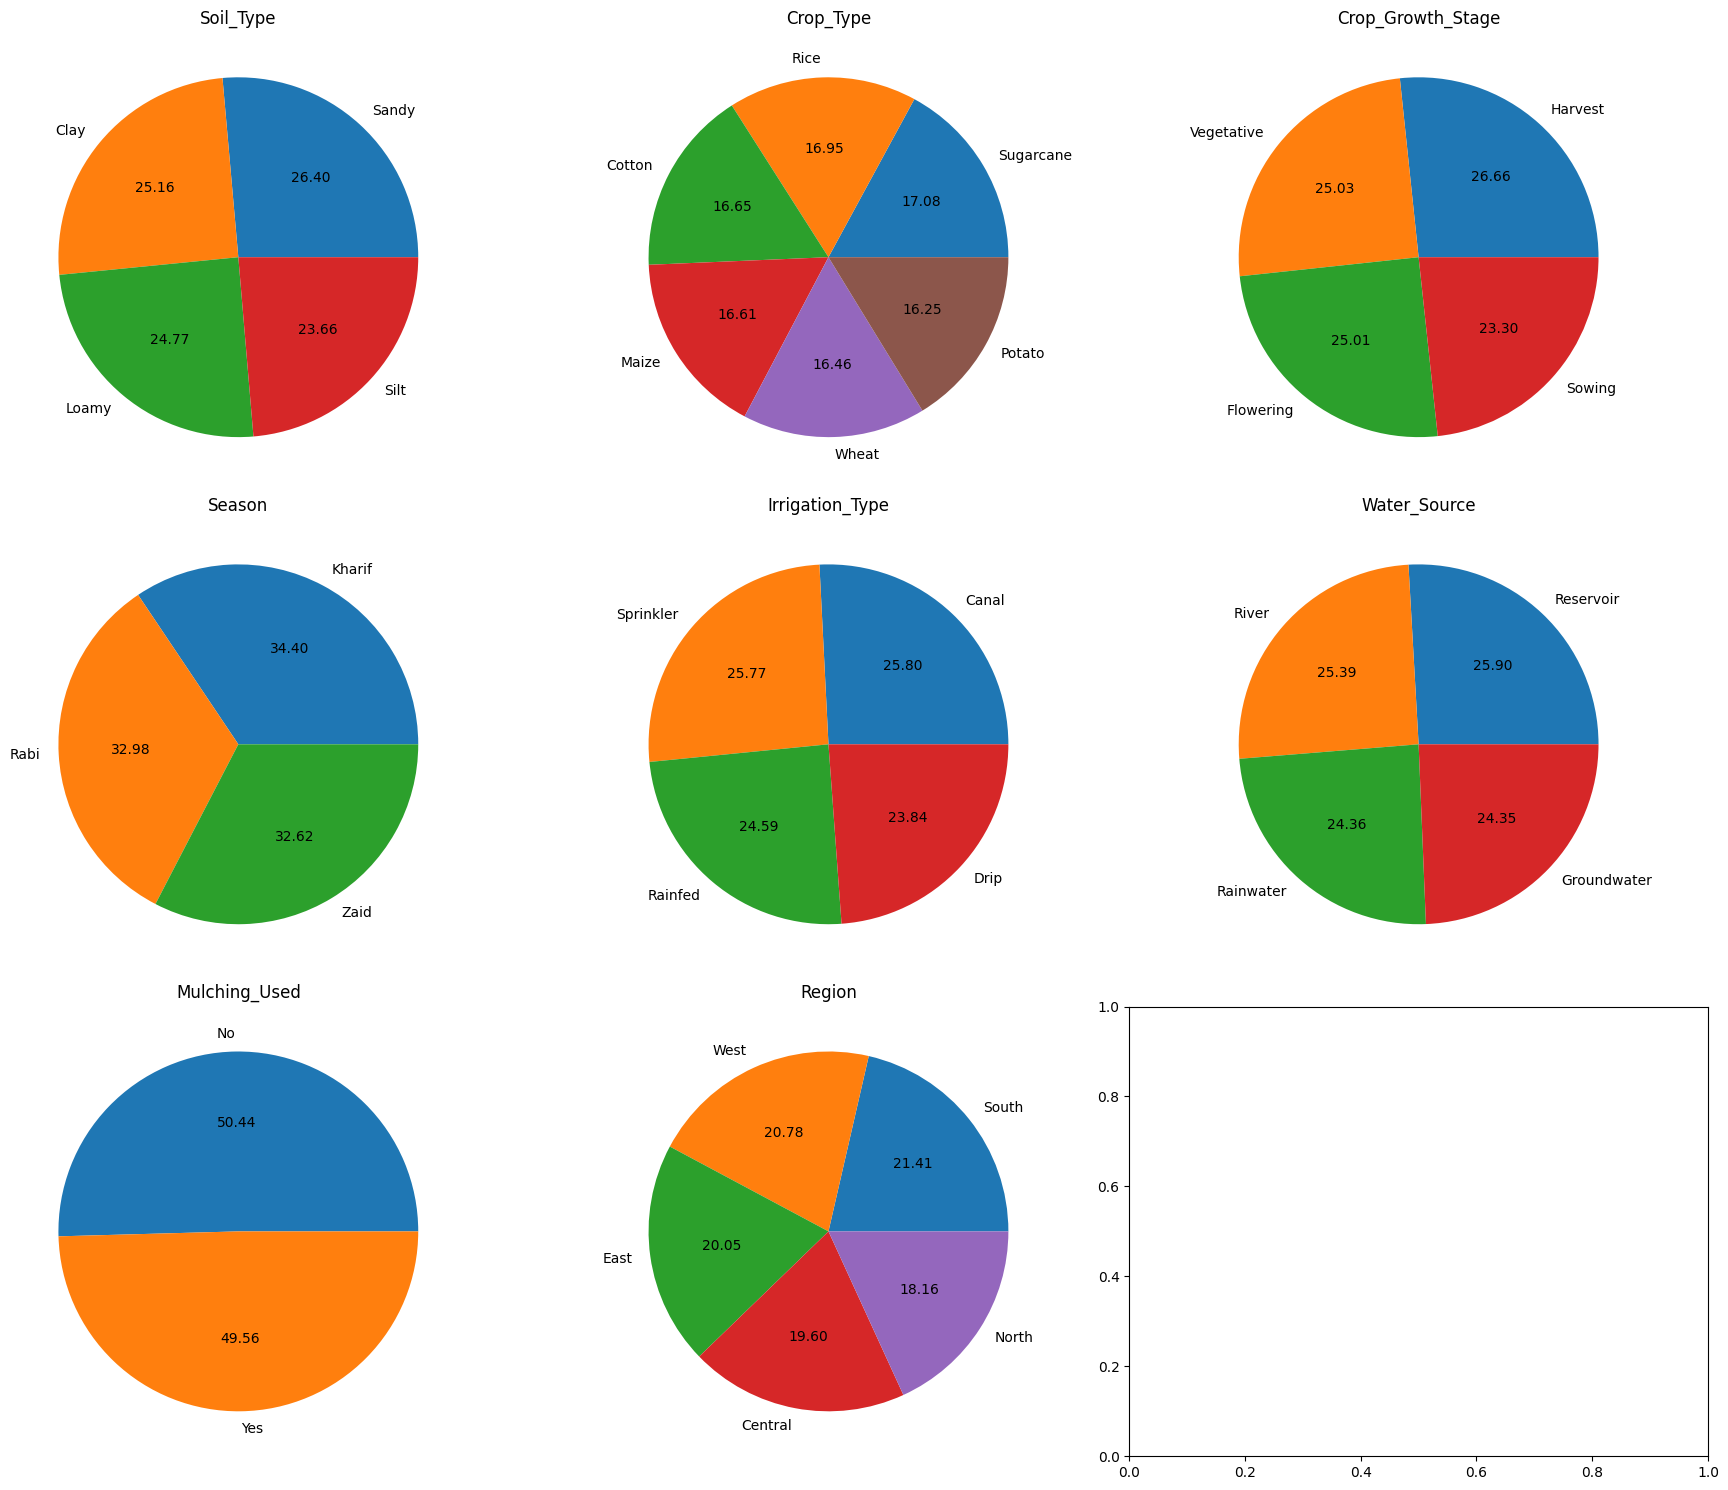

In [59]:
Cat_Cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type',
            'Water_Source','Mulching_Used', 'Region'] 

fig , axes = plt.subplots(3,3, figsize=(18, 15))
axes = axes.flatten()

for i , col in enumerate(Cat_Cols):
    test_data[col].value_counts().plot(kind='pie', autopct='%.2f' , ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')
plt.tight_layout()
plt.show()

## Univariate Analysis on Numerical Features

In [ ]:
Num_Cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C',
           'Humidity', 'Rainfall_mm','Sunlight_Hours', 'Wind_Speed_kmh',
            'Field_Area_hectare','Previous_Irrigation_mm' ]
fig , axes = plt.subplots(11,2, figsize=(20, 64))
axes = axes.flatten()
for i ,col in enumerate(Num_Cols):
    idx = i * 2
    sns.boxplot(train_data[col] , ax=axes[idx])
    axes[idx].set_title(col)
    
    sns.kdeplot(train_data[col] , ax=axes[idx+1])
    axes[idx].set_title(col)
    
plt.tight_layout()
plt.show()

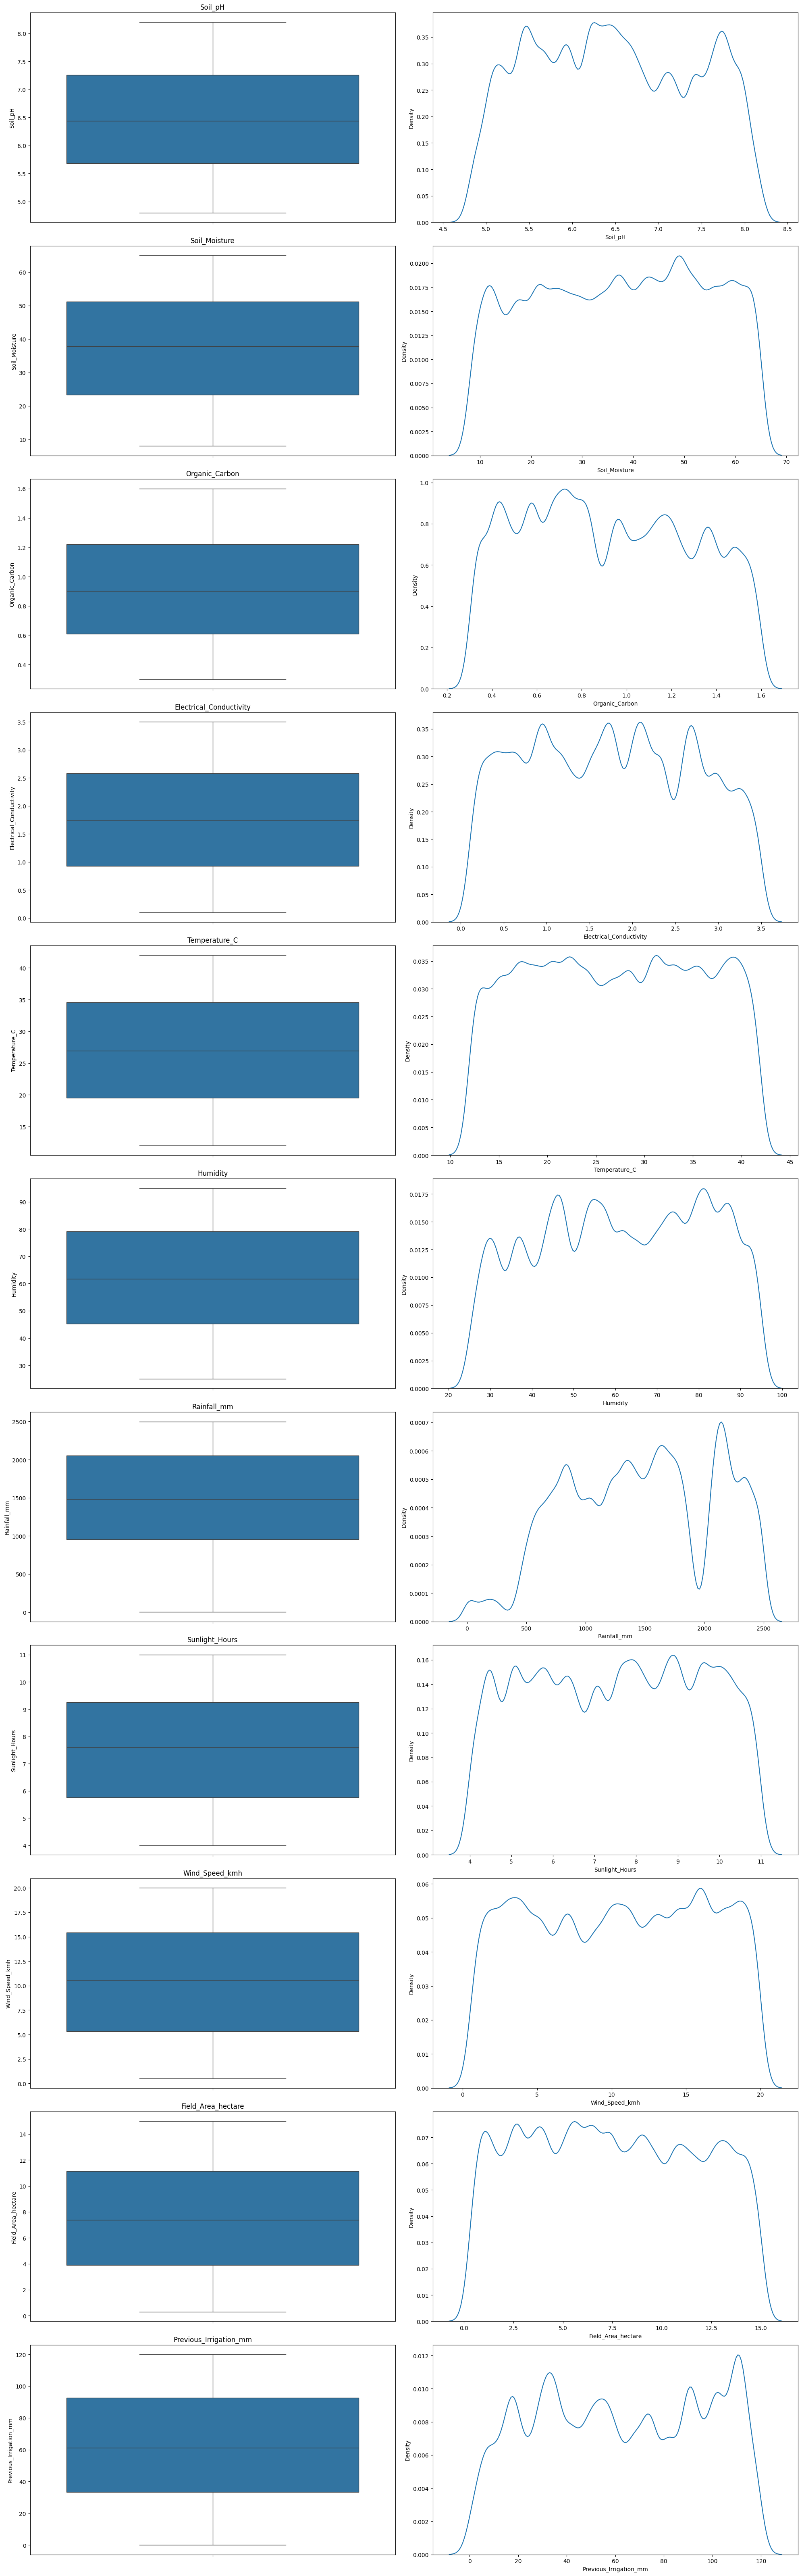

In [90]:
Num_Cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C',
           'Humidity', 'Rainfall_mm','Sunlight_Hours', 'Wind_Speed_kmh',
            'Field_Area_hectare','Previous_Irrigation_mm' ]
fig , axes = plt.subplots(11, 2, figsize=(20,64))
axes = axes.flatten()
for i , col in enumerate(Num_Cols):
    idx = i*2
    sns.boxplot(test_data[col], ax=axes[idx])
    axes[idx].set_title(col)
    sns.kdeplot(test_data[col], ax=axes[idx+1])
    axes[idx].set_title(col)

plt.tight_layout()
plt.show()